# Task (a): Misclassification without covariates

Reference: Hjort, *Logistic regression with errors in outcome classification*, §2.

Real labels $y_i\stackrel{\text{iid}}{\sim}\mathrm{Bern}(p)$; observed labels $\widehat y_i$ with
$\Pr(\widehat y_i=1\mid y_i=1)=1-\varepsilon$ and $\Pr(\widehat y_i=0\mid y_i=0)=1-\delta$.

## Derivation

$$
\widehat y_i\sim\mathrm{Bern}(p^\ast),\qquad p^\ast=\delta+p\,(1-\varepsilon-\delta).
$$

Moment inversion of $p^\ast\mapsto p$ gives the corrected estimator

$$
\widehat p=\frac{\bar y^\ast-\delta}{1-\varepsilon-\delta},\qquad
\mathbb E\,\widehat p=p,\qquad
\mathrm{Var}\,\widehat p=\frac{1}{n}\,\frac{p^\ast(1-p^\ast)}{(1-\varepsilon-\delta)^2}.
$$

Identifiability fails only at $\varepsilon+\delta=1$. For $\varepsilon+\delta>1$ ("Hansen the liar") the slope is negative but inversion still works.

## Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

project_root = Path().resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from helper_functions.styling import set_latex_plot_style
set_latex_plot_style(use_tex=False)

rng = np.random.default_rng(6114)


def simulate(n, p, eps, delta, rng):
    y = rng.binomial(1, p, size=n)
    flip1 = (y == 1) & (rng.uniform(size=n) < eps)
    flip0 = (y == 0) & (rng.uniform(size=n) < delta)
    y_hat = y.copy()
    y_hat[flip1] = 0
    y_hat[flip0] = 1
    return y_hat


def corrected(y_hat, eps, delta):
    p_star = y_hat.mean()
    denom = 1.0 - eps - delta
    p_hat = (p_star - delta) / denom
    se = np.sqrt(p_star * (1 - p_star) / len(y_hat)) / abs(denom)
    return p_hat, se

## Bias, variance, and identifiability across the full $\varepsilon$-grid

Symmetric noise $\varepsilon=\delta\in[0,0.99]$, $p=0.3$, $n=1000$, $B=4000$ Monte-Carlo draws per level.
The grid is dense near the identifiability boundary $\varepsilon=0.5$ (where the estimator's variance diverges) and also covers Hansen's regime $\varepsilon\to 1$.

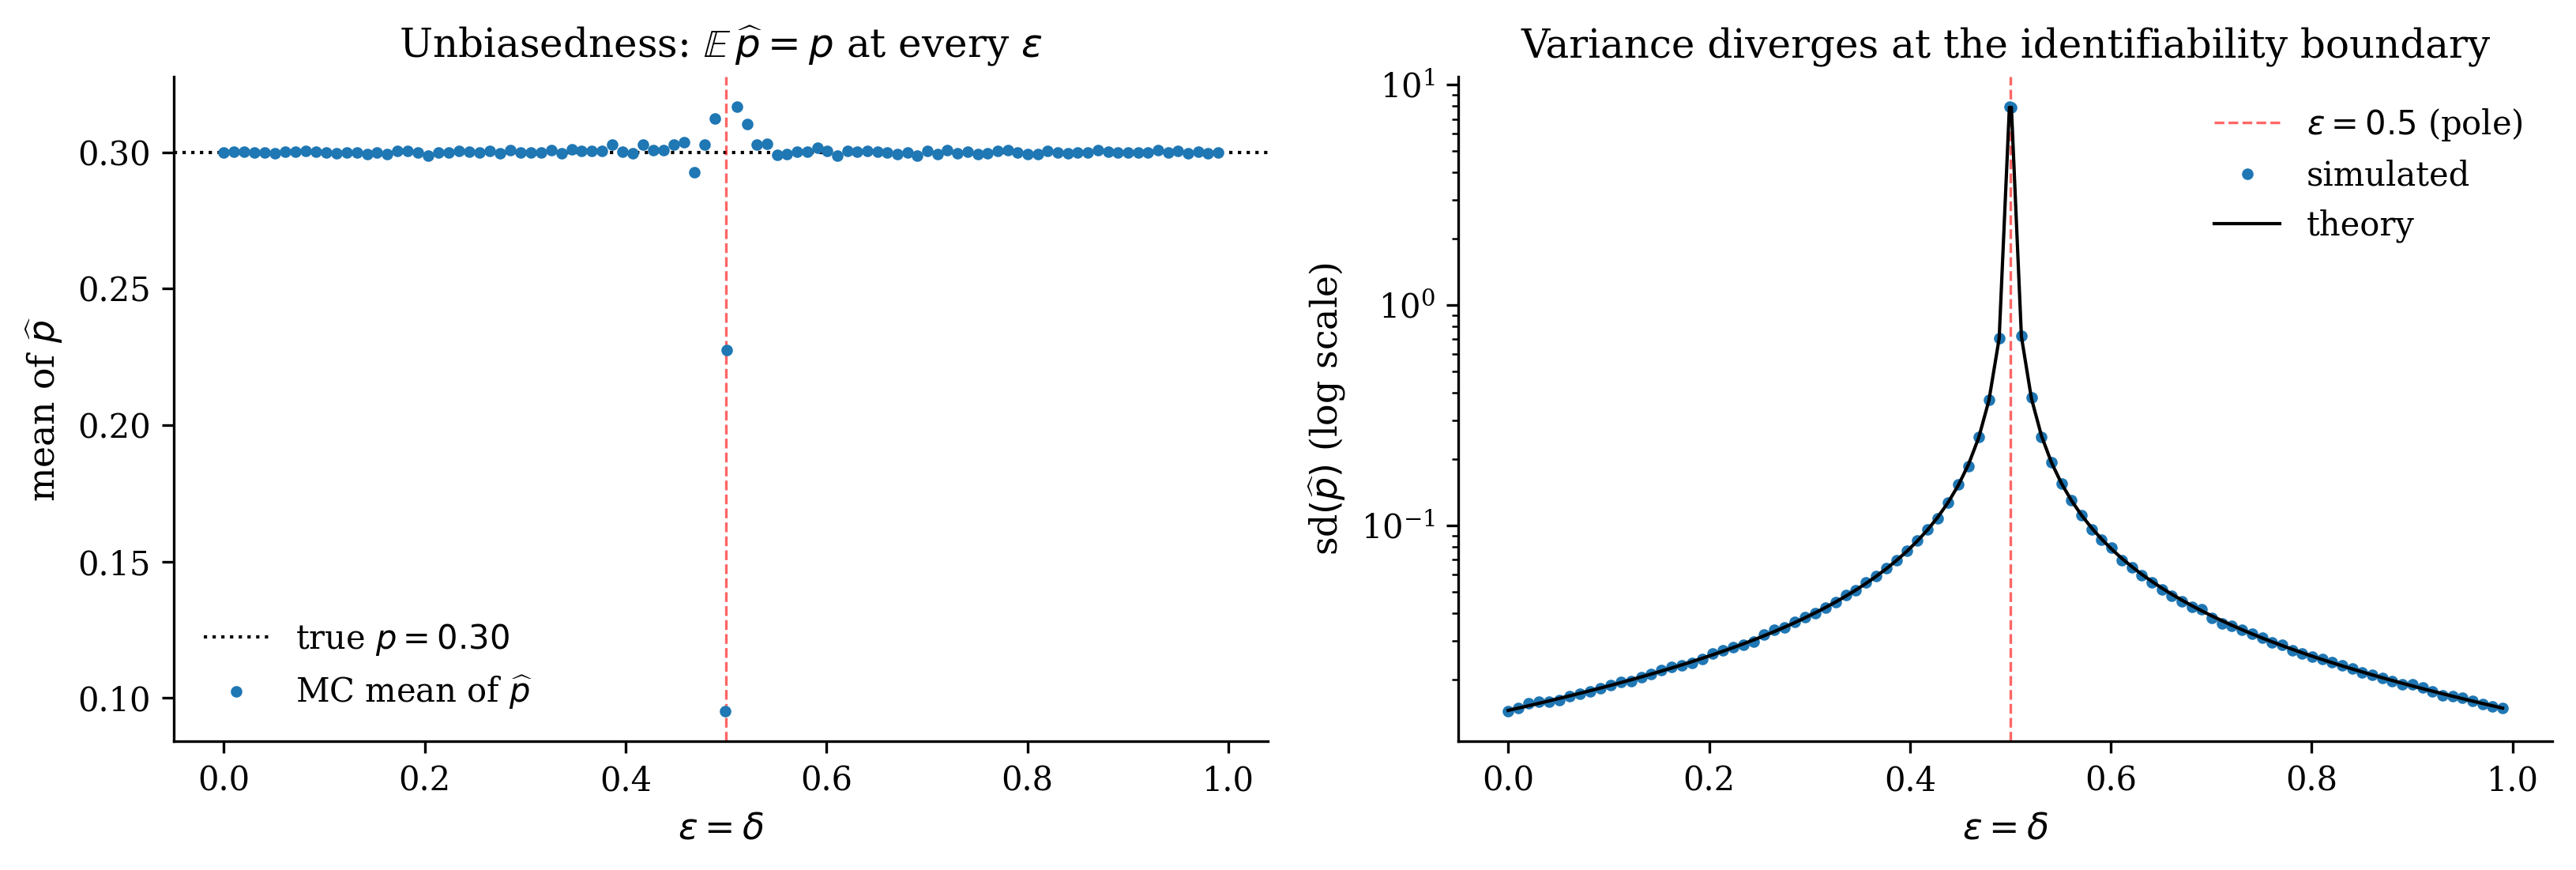

In [2]:
p_true, n, B = 0.30, 1000, 4000
# Dense near 0.5 to show the pole; exact 0.5 would be 0/0, so we stop at 0.499
left = np.linspace(0.0, 0.499, 50)
right = np.linspace(0.501, 0.99, 50)
eps_grid = np.concatenate([left, right])

mean_hat = np.empty_like(eps_grid)
sd_hat = np.empty_like(eps_grid)
for k, eps in enumerate(eps_grid):
    ests = np.array([corrected(simulate(n, p_true, eps, eps, rng), eps, eps)[0]
                     for _ in range(B)])
    mean_hat[k] = ests.mean()
    sd_hat[k] = ests.std(ddof=1)

p_star = p_true + eps_grid * (1 - 2 * p_true)
sd_theory = np.sqrt(p_star * (1 - p_star) / n) / np.abs(1 - 2 * eps_grid)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].axhline(p_true, color='k', ls=':', lw=1, label=r'true $p=0.30$')
axes[0].axvline(0.5, color='r', ls='--', lw=0.8, alpha=0.6)
axes[0].plot(eps_grid, mean_hat, 'o', ms=2.5, label=r'MC mean of $\widehat p$')
axes[0].set_xlabel(r'$\varepsilon=\delta$')
axes[0].set_ylabel(r'mean of $\widehat p$')
axes[0].set_title(r'Unbiasedness: $\mathbb{E}\,\widehat p=p$ at every $\varepsilon$')
axes[0].legend()

axes[1].axvline(0.5, color='r', ls='--', lw=0.8, alpha=0.6, label=r'$\varepsilon=0.5$ (pole)')
axes[1].plot(eps_grid, sd_hat, 'o', ms=2.5, label='simulated')
axes[1].plot(eps_grid, sd_theory, 'k-', lw=1, label='theory')
axes[1].set_yscale('log')
axes[1].set_xlabel(r'$\varepsilon=\delta$')
axes[1].set_ylabel(r'sd$(\widehat p)$ (log scale)')
axes[1].set_title(r'Variance diverges at the identifiability boundary')
axes[1].legend()
plt.tight_layout()
plt.show()

## Wald confidence interval coverage

$\widehat p\pm z_{0.975}\,\widehat{\mathrm{sd}}(\widehat p)$ with $\widehat{\mathrm{sd}}$ from the delta method.

In [3]:
p_true, n, B = 0.30, 1000, 5000
z = norm.ppf(0.975)

scenarios = [(0.00, 0.00), (0.10, 0.10), (0.10, 0.20),
             (0.30, 0.30), (0.45, 0.45), (0.99, 0.99)]

print('{:>6} {:>6} {:>10} {:>12}'.format('eps', 'delta', 'coverage', 'mean width'))
for eps, delta in scenarios:
    cov, widths = 0, np.empty(B)
    for b in range(B):
        p_hat, se = corrected(simulate(n, p_true, eps, delta, rng), eps, delta)
        lo, hi = p_hat - z*se, p_hat + z*se
        cov += int(lo <= p_true <= hi)
        widths[b] = hi - lo
    print(f'{eps:>6.2f} {delta:>6.2f} {cov/B:>10.3f} {widths.mean():>12.4f}')

   eps  delta   coverage   mean width
  0.00   0.00      0.951       0.0568
  0.10   0.10      0.947       0.0734
  0.10   0.20      0.951       0.0870
  0.30   0.30      0.954       0.1529
  0.45   0.45      0.952       0.6190
  0.99   0.99      0.948       0.0581
